In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt

import torch
import ili
from ili.dataloaders import NumpyLoader
from ili.inference import InferenceRunner 
from ili.validation.metrics import PosteriorCoverage, PlotSinglePosterior
from ili.dataloaders import StaticNumpyLoader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
os.chdir('/mnt/home/fmaion/packages/bias_tools/src/')
import cutter as cutter

In [4]:
import pickle
import json

basepath = '/mnt/ceph/users/fmaion/projects/bias_priors/training_results/bias_NPE_large_log_bs_v2/'

with open(basepath+'bias_NPE_large_log_bs_v2_posterior.pkl', 'rb') as f:
    # This loads the object exactly as it was saved
    posterior_ensemble = pickle.load(f)

with open(basepath+'bias_NPE_large_log_bs_v2_summary.json', 'rb') as f:
    summaries = json.load(f)

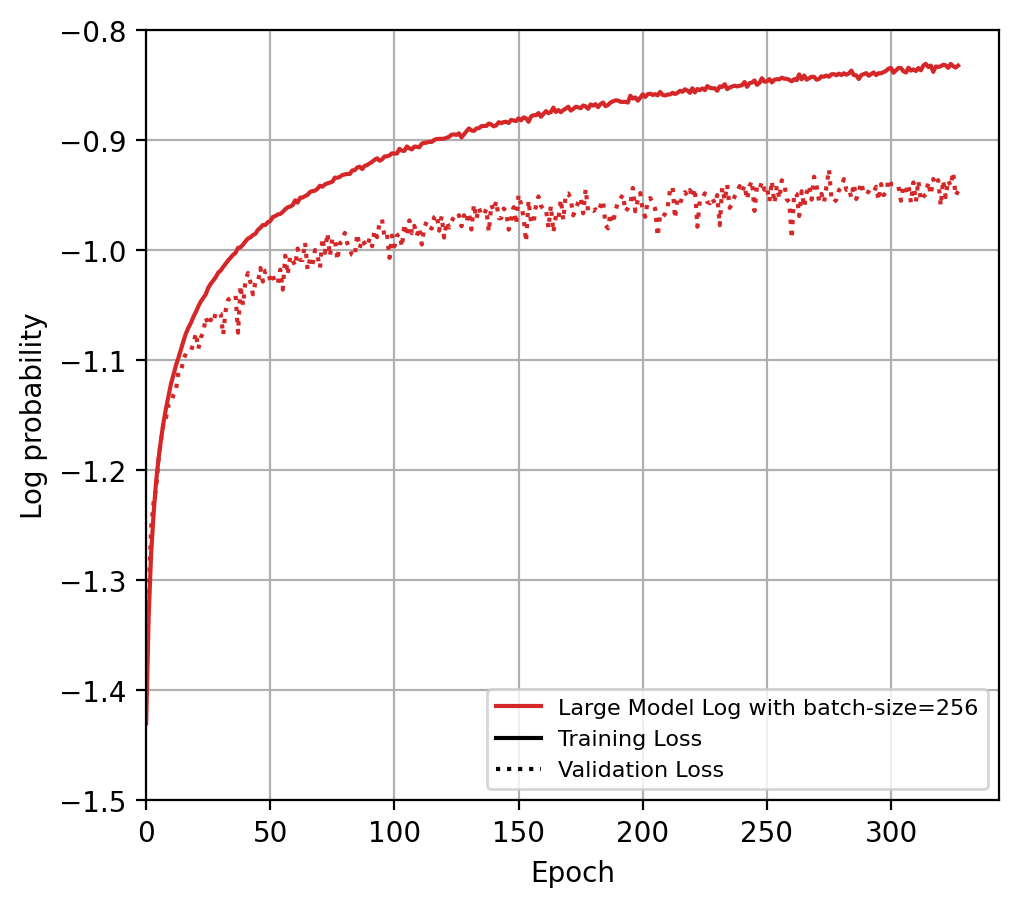

In [29]:
# plot train/validation loss
fig, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=200)

# Large Model Log + small batch-size
ax.plot(np.array(summaries[0]['training_log_probs']),
        ls='-', label="Large Model Log with batch-size=256", color="C3")
ax.plot(np.array(summaries[0]['validation_log_probs']),
        ls=':', color="C3")

ax.plot(np.zeros(10), np.zeros(10), color='k', label="Training Loss")
ax.plot(np.zeros(10), np.zeros(10), color='k', ls=':', label="Validation Loss")
ax.set_ylim(-1.5,-0.8)

ax.set_xlim(0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend(fontsize=8, loc='lower right')

plt.grid()

In [9]:
data_name = 'bias_NPE_log.yaml'
infer_name = 'bias_NPE_large_log_bs_v2.yaml'

# Load Training Data
all_loader = StaticNumpyLoader.from_config("/mnt/home/fmaion/storage/projects/bias_priors/scripts/configs/data/"+data_name)

## Testing NPE for one single value of parameters

In [18]:
all_loader.x.shape

(735496, 36)

100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


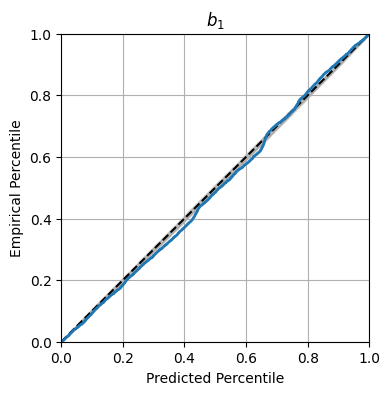

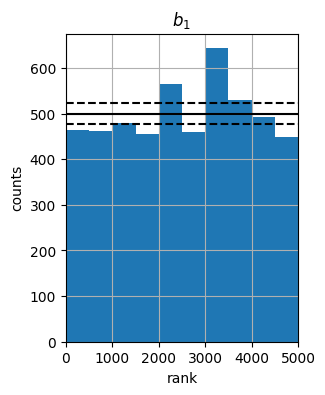

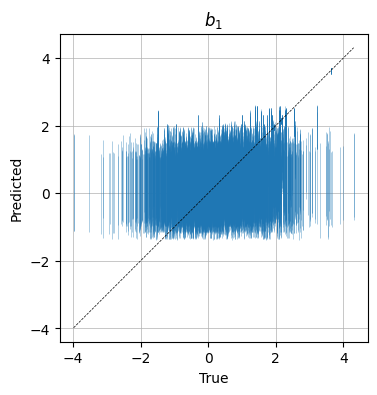

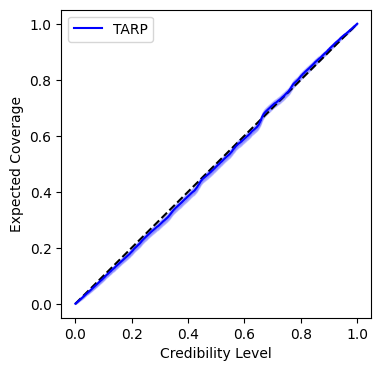

In [26]:
# Drawing samples from the ensemble posterior

dim_theta = 1

metric = PosteriorCoverage(
    num_samples=5000, sample_method='direct', 
    labels=["$b_1$"],
    plot_list = ["coverage", "histogram", "predictions", "tarp"],
    out_dir=None
)

fig = metric(
    posterior=posterior_ensemble,
    x=all_loader.x[:5000,:], theta=all_loader.theta[:5000, :dim_theta]
)